<a href="https://colab.research.google.com/github/Chandini-M555/Data_Science_Task/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LINEAR REGRESSION

**California House price prediction**

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
#from sklearn import datasets
#dir(datasets) it displays all datasets present in it
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Data preparation

In [149]:

data=fetch_california_housing()
#data.keys
df=pd.DataFrame(data.data,columns=data.feature_names)
df[data.target_names[0]]=data.target #addimg output column to df
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [150]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

cleaning is skipped bcoz evrything is clean

# **`EDA`**

In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [152]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [153]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: xlabel='MedHouseVal', ylabel='Count'>

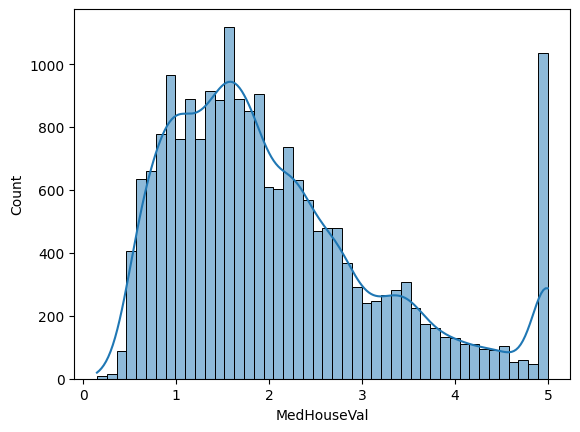

In [154]:
sns.histplot(x="MedHouseVal",data=df,kde=True)

<Axes: xlabel='HouseAge', ylabel='Count'>

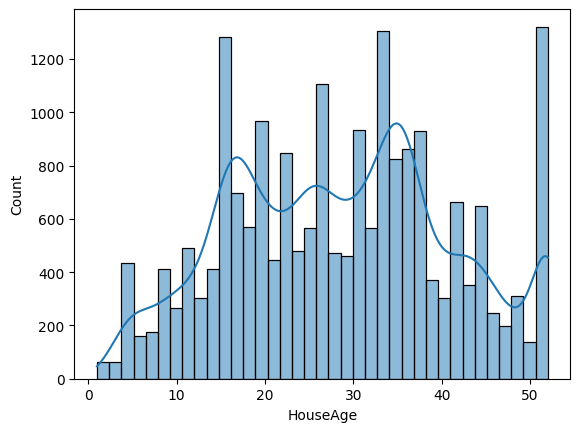

In [155]:
sns.histplot(x="HouseAge",data=df,kde=True)

#**Correlation**

<Axes: >

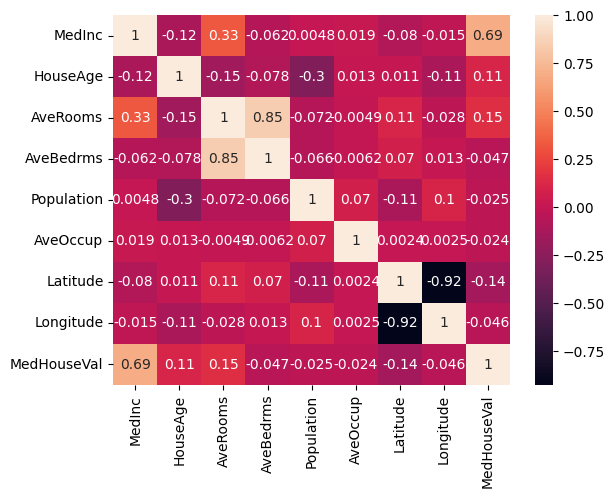

In [156]:

data=df.corr()
sns.heatmap(data,annot=True)

In [157]:
#sns.pairplot(df)

Text(0, 0.5, 'MedHouseVal')

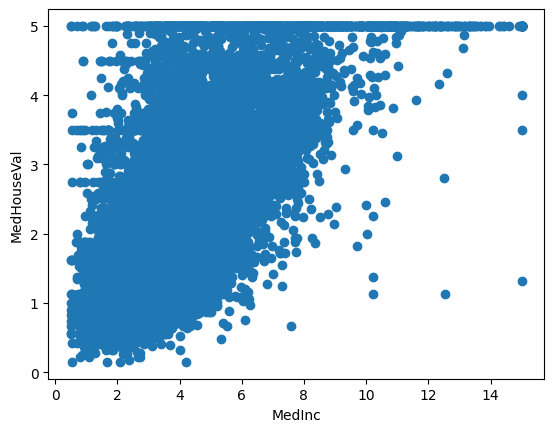

In [158]:
plt.scatter(x=df['MedInc'],y=df['MedHouseVal'])
plt.xlabel('MedInc')
plt.ylabel("MedHouseVal")

# **Model Training**

In [159]:
#Divide the data into input and output
x=df.drop('MedHouseVal',axis=1) #removing target col
y=df['MedHouseVal']

In [160]:
#ML-rules -->>100%-->70%(training),30%(testing)
#splitting data into training and testing data
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,test_size=0.3,random_state=42) #can also use train_size=0.7
# Xtrain
# Xtest
# Ytrain
# Ytest                                                                  #random state always 42

In [161]:
# Model training
#multi linear regression=more than 2 cols
model=LinearRegression()
model.fit(Xtrain,Ytrain)   #always training data should be given


LinearRegression()

In [162]:
print("Intercept: ",model.intercept_)
print("Scope: ",model.coef_) #we have 8 cols so we get 8 diff slopes


Intercept:  -37.05624133152533
Scope:  [ 4.45822565e-01  9.68186799e-03 -1.22095112e-01  7.78599557e-01
 -7.75740400e-07 -3.37002667e-03 -4.18536747e-01 -4.33687976e-01]


# **Model Prediction**

In [163]:
Ypred=model.predict(Xtest)
Ypred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

# **Model Evaluation**

In [164]:
print("Metrics: ")
r2=r2_score(Ytest,Ypred)
print("R2: ",r2)
N=df.shape[0]
P=df.shape[1]
adj_r2=1-(((1-r2**2)*(N-1))/N-P-1)
print("Adj R2: ",adj_r2)
print("MSE: ",mean_squared_error(Ytest,Ypred))
print("MAE: ",mean_absolute_error(Ytest,Ypred))


Metrics: 
R2:  0.595770232606166
Adj R2:  10.354973422861443
MSE:  0.5305677824766758
MAE:  0.5272474538305952


Training          Testing        Bias        Variance

high                 high            low           low

high                 low             low           high

low                 low              high          high



generalized model-->a model is working well for both training ds and testing ds or when we have low bias and low variance

overfitting prblm-->if model is working well for training ds and not for testing ds or when we have low bias and high variance

underfitting prblm--if model is not working well for both training and testing ds or when we have high bias and high variance


In [165]:
#type of model (gen,over,under)
print("training efficiency: ",model.score(Xtrain,Ytrain))
print("testing efficiency: ",model.score(Xtest,Ytest))

training efficiency:  0.609345972797216
testing efficiency:  0.595770232606166


In [166]:
#scaling -after splitting we need to do standard scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
Xtrain_scaled=scaler.fit_transform(Xtrain) #only for input features we do scaling
Xtest_scaled=scaler.transform(Xtest) #avoid the data leakage-we dont use fit_tranform



In [167]:
#creating new ds and predicting
new_data=df.iloc[:1,:-1]
pred=model.predict(new_data)[0]
print("predicted price: ",pred*100000)

predicted price:  414333.44149255333


# Car price prediction

In [168]:
df=pd.read_csv("car_price_prediction.csv")
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [169]:
df.isnull().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [170]:
df.drop_duplicates(inplace=True)
df.shape

(18924, 18)

In [171]:
for col in df.columns:
  if df[col].dtype=="object":
    print(col)
    print(df[col].unique())

Levy
['1399' '1018' '-' '862' '446' '891' '761' '751' '394' '1053' '1055'
 '1079' '810' '2386' '1850' '531' '586' '1249' '2455' '583' '1537' '1288'
 '915' '1750' '707' '1077' '1486' '1091' '650' '382' '1436' '1194' '503'
 '1017' '1104' '639' '629' '919' '781' '530' '640' '765' '777' '779' '934'
 '769' '645' '1185' '1324' '830' '1187' '1111' '760' '642' '1604' '1095'
 '966' '473' '1138' '1811' '988' '917' '1156' '687' '11714' '836' '1347'
 '2866' '1646' '259' '609' '697' '585' '475' '690' '308' '1823' '1361'
 '1273' '924' '584' '2078' '831' '1172' '893' '1872' '1885' '1266' '447'
 '2148' '1730' '730' '289' '502' '333' '1325' '247' '879' '1342' '1327'
 '1598' '1514' '1058' '738' '1935' '481' '1522' '1282' '456' '880' '900'
 '798' '1277' '442' '1051' '790' '1292' '1047' '528' '1211' '1493' '1793'
 '574' '930' '1998' '271' '706' '1481' '1677' '1661' '1286' '1408' '1090'
 '595' '1451' '1267' '993' '1714' '878' '641' '749' '1511' '603' '353'
 '877' '1236' '1141' '397' '784' '1024' '1357' '13

In [172]:
df=df.drop(["ID","Doors"],axis=1)
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,Left wheel,Silver,4


In [173]:
#clean levy
df["Levy"]=df["Levy"].replace("-",np.nan)
df["Levy"]=df["Levy"].astype(float)
avg=round(df["Levy"].mean(),2)
df["Levy"]=df["Levy"].fillna(avg)
df["Levy"].unique()

array([ 1399. ,  1018. ,   906.3,   862. ,   446. ,   891. ,   761. ,
         751. ,   394. ,  1053. ,  1055. ,  1079. ,   810. ,  2386. ,
        1850. ,   531. ,   586. ,  1249. ,  2455. ,   583. ,  1537. ,
        1288. ,   915. ,  1750. ,   707. ,  1077. ,  1486. ,  1091. ,
         650. ,   382. ,  1436. ,  1194. ,   503. ,  1017. ,  1104. ,
         639. ,   629. ,   919. ,   781. ,   530. ,   640. ,   765. ,
         777. ,   779. ,   934. ,   769. ,   645. ,  1185. ,  1324. ,
         830. ,  1187. ,  1111. ,   760. ,   642. ,  1604. ,  1095. ,
         966. ,   473. ,  1138. ,  1811. ,   988. ,   917. ,  1156. ,
         687. , 11714. ,   836. ,  1347. ,  2866. ,  1646. ,   259. ,
         609. ,   697. ,   585. ,   475. ,   690. ,   308. ,  1823. ,
        1361. ,  1273. ,   924. ,   584. ,  2078. ,   831. ,  1172. ,
         893. ,  1872. ,  1885. ,  1266. ,   447. ,  2148. ,  1730. ,
         730. ,   289. ,   502. ,   333. ,  1325. ,   247. ,   879. ,
        1342. ,  132

In [174]:
mode=df["Manufacturer"].mode()[0]
df["Manufacturer"]=df["Manufacturer"].str.replace("სხვა",mode)
df["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'HAVAL', 'HUMMER', 'SCION', 'UAZ',
       'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [175]:
#df["Leather interior"].unique()
#df["Fuel type"].unique()
#df["Engine volume"].unique()
df["Engine volume"]=df["Engine volume"].str.strip("Turbo")
df["Engine volume"]=df["Engine volume"].astype(float)
df["Engine volume"].unique()

array([ 3.5,  3. ,  1.3,  2.5,  2. ,  1.8,  2.4,  4. ,  1.6,  3.3,  2.2,
        4.7,  1.5,  4.4,  1.4,  3.6,  2.3,  5.5,  2.8,  3.2,  3.8,  4.6,
        1.2,  5. ,  1.7,  2.9,  0.5,  1.9,  2.7,  4.8,  5.3,  0.4,  1.1,
        2.1,  0.7,  5.4,  3.7,  1. ,  2.6,  0.8,  0.2,  5.7,  6.7,  6.2,
        3.4,  6.3,  4.3,  4.2,  0. , 20. ,  0.3,  5.9,  5.6,  6. ,  0.6,
        6.8,  4.5,  7.3,  0.1,  3.1,  6.4,  3.9,  0.9,  5.2,  5.8])

In [176]:
# df["Mileage"].unique()
df["Mileage"]=df["Mileage"].str.strip(" km")
df["Mileage"]=df["Mileage"].astype(float)
df["Mileage"].unique()

array([186005., 192000., 200000., ..., 140607., 307325., 186923.])

In [181]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
for col in df.columns:
  if df[col].dtype=="object":
    df[col]=encoder.fit_transform(df[col])
df.head()


,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,542,325,32,1242,43,4,1,2,35,5845,5,0,0,0,12,12
1,752,218,8,658,44,4,0,5,30,5948,5,2,0,0,1,8
2,317,186,21,684,39,3,0,5,13,6112,3,3,1,1,1,2
3,141,168,16,661,44,4,1,2,25,5479,3,0,0,0,14,0
4,451,36,21,684,47,3,1,5,13,3000,3,0,1,0,12,4


<Axes: >

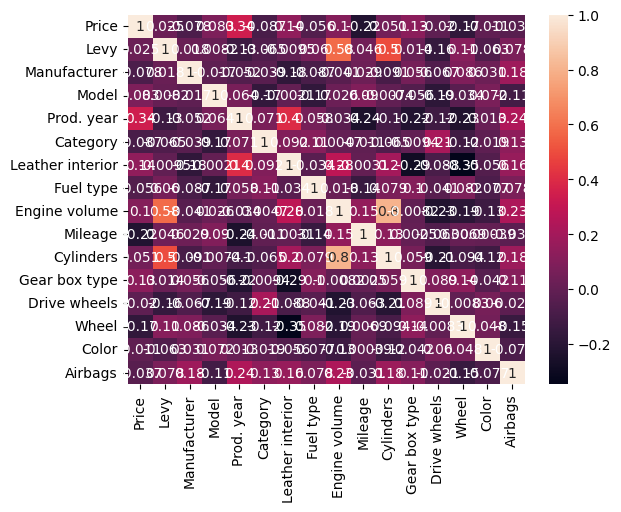

In [182]:
data=df.corr()
sns.heatmap(data,annot=True)

In [185]:

#Divide the data into input and output
x=df.drop('Price',axis=1) #removing target col
y=df['Price']

In [188]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [189]:
model=LinearRegression()
model.fit(Xtrain,Ytrain)

LinearRegression()

In [190]:
print("Intercept: ",model.intercept_)
print("Scope: ",model.coef_)

Intercept:  -1089.406122271152
Scope:  [ 1.39069510e-01 -8.92220550e-01  6.58852282e-02  4.32649646e+01
 -2.22774784e+01  6.57805517e+00 -3.03057236e+01  1.37816171e+01
 -4.24479385e-02 -8.91628958e+00  1.71183533e+02  6.36397792e+01
 -2.30736170e+02 -7.23479064e-01 -2.67015380e+01]


In [193]:
Ypred=model.predict(Xtest)
Ypred

array([627.37706467, 383.37576473, 921.27196219, ..., 883.80527488,
       754.54290982, 657.1341393 ])

In [194]:
print("Metrics: ")
r2=r2_score(Ytest,Ypred)
print("R2: ",r2)
N=df.shape[0]
P=df.shape[1]
adj_r2=1-(((1-r2**2)*(N-1))/N-P-1)
print("Adj R2: ",adj_r2)
print("MSE: ",mean_squared_error(Ytest,Ypred))
print("MAE: ",mean_absolute_error(Ytest,Ypred))


Metrics: 
R2:  0.2452759602262894
Adj R2:  17.060209960568084
MSE:  259647.2567706424
MAE:  410.70981344557777


In [195]:
#type of model (gen,over,under)
print("training efficiency: ",model.score(Xtrain,Ytrain))
print("testing efficiency: ",model.score(Xtest,Ytest))
#underfitting

training efficiency:  0.2749544910573404
testing efficiency:  0.2452759602262894
